# 7.3 过拟合、欠拟合与正则化

> **模块七：模型评估与优化** | NOAI竞赛课程
>
> 本节约 **2课时**，重点理解模型复杂度对性能的影响及正则化技术

---

## 📚 学习目标

1. 理解偏差-方差权衡（Bias-Variance Tradeoff）
2. 识别过拟合和欠拟合的表现与原因
3. 掌握L1正则化（Lasso）、L2正则化（Ridge）和Elastic Net
4. 了解Early Stopping技术
5. 通过多项式回归实验可视化过拟合/欠拟合现象

---

## 1. 偏差-方差权衡（Bias-Variance Tradeoff）

### 1.1 预测误差的分解

模型的预测误差可以分解为三个部分：

$$\text{总误差} = \text{偏差}^2 + \text{方差} + \text{不可约误差}$$

### 1.2 偏差（Bias）

- **定义**：模型预测的期望值与真实值之间的差异
- **高偏差**意味着模型**过于简单**，无法捕捉数据中的模式
- 对应**欠拟合**（Underfitting）

$$\text{Bias}^2 = \mathbb{E}\left[(\hat{f}(x) - f(x))^2\right]$$

### 1.3 方差（Variance）

- **定义**：不同训练集上训练出的模型预测值的波动程度
- **高方差**意味着模型**过于复杂**，对训练数据过度敏感
- 对应**过拟合**（Overfitting）

$$\text{Variance} = \mathbb{E}\left[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\right]$$

### 1.4 权衡关系

```
模型复杂度上升 -> 偏差下降  方差上升  （过拟合方向）
模型复杂度下降 -> 偏差上升  方差下降  （欠拟合方向）
目标：找到总误差最小的最优点
```

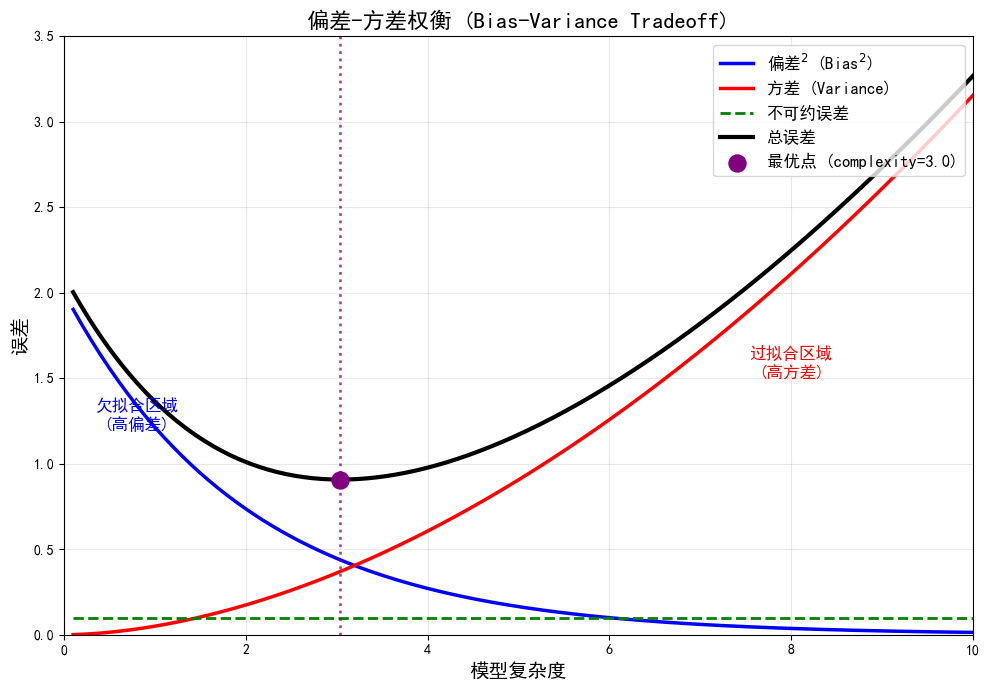

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ====== 偏差-方差权衡可视化（示意图）======
complexity = np.linspace(0.1, 10, 200)

# 模拟偏差、方差和总误差曲线
bias_sq = 2.0 * np.exp(-0.5 * complexity)
variance = 0.05 * complexity ** 1.8
irreducible = 0.1 * np.ones_like(complexity)
total_error = bias_sq + variance + irreducible

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(complexity, bias_sq, 'b-', linewidth=2.5, label=r'偏差$^2$ (Bias$^2$)')
ax.plot(complexity, variance, 'r-', linewidth=2.5, label='方差 (Variance)')
ax.plot(complexity, irreducible, 'g--', linewidth=2, label='不可约误差')
ax.plot(complexity, total_error, 'k-', linewidth=3, label='总误差')

# 标注最优点
optimal_idx = np.argmin(total_error)
ax.axvline(x=complexity[optimal_idx], color='purple', linestyle=':', linewidth=2, alpha=0.7)
ax.scatter([complexity[optimal_idx]], [total_error[optimal_idx]],
           color='purple', s=150, zorder=5, label=f'最优点 (complexity={complexity[optimal_idx]:.1f})')

# 标注区域
ax.annotate('欠拟合区域\n(高偏差)', xy=(0.8, 1.2), fontsize=12, color='blue',
            ha='center', fontweight='bold')
ax.annotate('过拟合区域\n(高方差)', xy=(8, 1.5), fontsize=12, color='red',
            ha='center', fontweight='bold')

ax.set_xlabel('模型复杂度', fontsize=14)
ax.set_ylabel('误差', fontsize=14)
ax.set_title('偏差-方差权衡 (Bias-Variance Tradeoff)', fontsize=16)
ax.legend(loc='upper right', fontsize=12)
ax.set_xlim(0, 10)
ax.set_ylim(0, 3.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 2. 过拟合与欠拟合

### 2.1 过拟合（Overfitting）

**表现：**
- 训练误差很低，但验证/测试误差很高
- 模型记住了训练数据的噪声和细节
- 模型在新数据上泛化能力差

**原因：**
- 模型太复杂（如多项式次数过高、神经网络层数过多）
- 训练数据太少
- 特征太多（维度灾难）
- 训练时间过长

### 2.2 欠拟合（Underfitting）

**表现：**
- 训练误差和验证/测试误差都很高
- 模型连训练数据的基本模式都没学到

**原因：**
- 模型太简单（如用线性模型拟合非线性数据）
- 特征太少或特征质量差
- 训练不足
- 正则化过强

### 2.3 诊断方法

| 现象 | 训练误差 | 验证误差 | 诊断 |
|------|---------|---------|------|
| 过拟合 | 很低 | 很高 | 模型太复杂 |
| 欠拟合 | 很高 | 很高 | 模型太简单 |
| 良好 | 适中 | 接近训练误差 | 适合 |

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


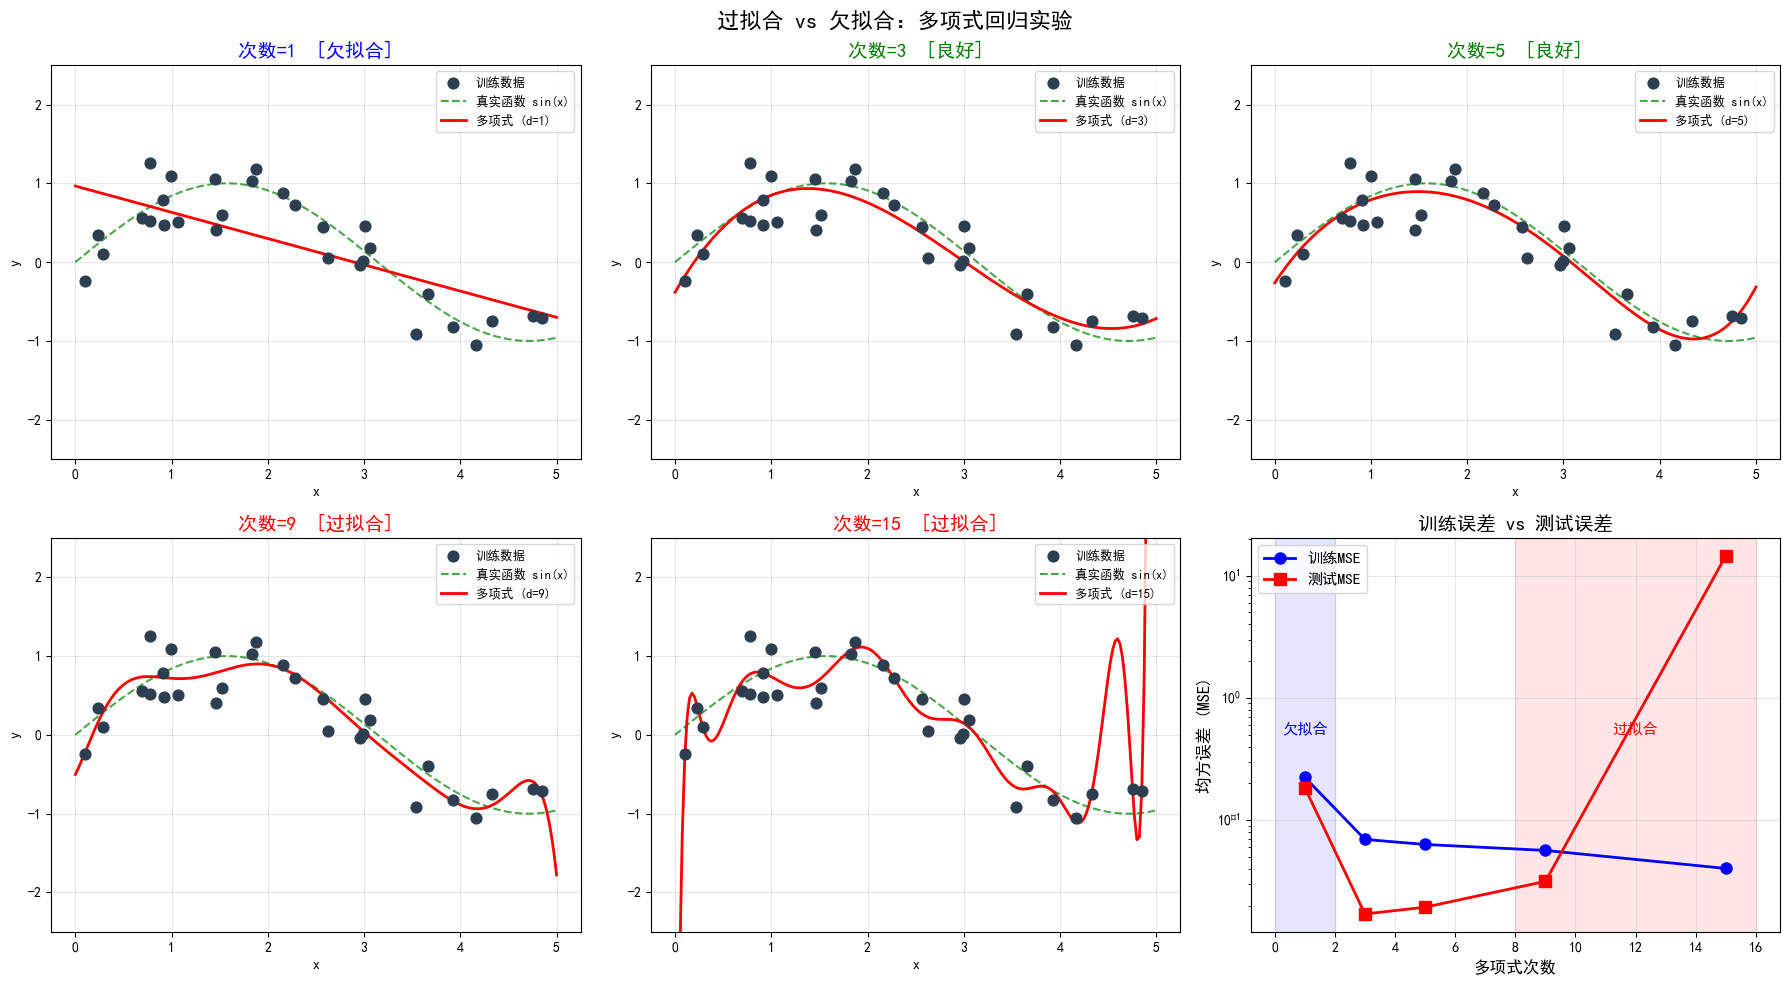

In [17]:
# ====== 多项式回归实验：可视化过拟合/欠拟合 ======
np.random.seed(42)

# 生成非线性数据
n_samples = 30
X_data = np.sort(5 * np.random.rand(n_samples))
y_data = np.sin(X_data) + np.random.randn(n_samples) * 0.3

X_data_2d = X_data.reshape(-1, 1)

# 测试数据（用于评估）
X_test_vis = np.linspace(0, 5, 200).reshape(-1, 1)
y_test_vis = np.sin(X_test_vis.ravel())

# 使用不同阶数的多项式
degrees = [1, 3, 5, 9, 15]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

train_errors = []
test_errors_list = []

for i, degree in enumerate(degrees):
    ax = axes[i]

    # 多项式特征变换
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_data_2d)
    X_test_poly = poly.transform(X_test_vis)

    # 训练
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y_data)

    # 预测
    y_pred_train = model_poly.predict(X_poly)
    y_pred_test = model_poly.predict(X_test_poly)

    # 误差
    train_mse = mean_squared_error(y_data, y_pred_train)
    test_mse = mean_squared_error(y_test_vis, y_pred_test)
    train_errors.append(train_mse)
    test_errors_list.append(test_mse)

    # 绘制
    ax.scatter(X_data, y_data, color='#2C3E50', s=60, zorder=5, label='训练数据')
    ax.plot(X_test_vis.ravel(), np.sin(X_test_vis.ravel()), 'g--',
            linewidth=1.5, alpha=0.7, label='真实函数 sin(x)')
    ax.plot(X_test_vis.ravel(), y_pred_test, 'r-',
            linewidth=2, label=f'多项式 (d={degree})')

    # 诊断标签
    if degree <= 1:
        diag = '欠拟合'
        color = 'blue'
    elif degree >= 9:
        diag = '过拟合'
        color = 'red'
    else:
        diag = '良好'
        color = 'green'

    ax.set_title(f'次数={degree}  [{diag}]', fontsize=14, color=color, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, alpha=0.3)

# 最后一个子图：误差曲线
ax = axes[5]
ax.plot(degrees, train_errors, 'b-o', linewidth=2, markersize=8, label='训练MSE')
ax.plot(degrees, test_errors_list, 'r-s', linewidth=2, markersize=8, label='测试MSE')
ax.set_xlabel('多项式次数', fontsize=12)
ax.set_ylabel('均方误差 (MSE)', fontsize=12)
ax.set_title('训练误差 vs 测试误差', fontsize=14)
ax.set_yscale('log')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# 标注区域
ax.axvspan(0, 2, alpha=0.1, color='blue')
ax.axvspan(8, 16, alpha=0.1, color='red')
ax.annotate('欠拟合', xy=(1, 0.5), fontsize=11, color='blue', ha='center', fontweight='bold')
ax.annotate('过拟合', xy=(12, 0.5), fontsize=11, color='red', ha='center', fontweight='bold')

plt.suptitle('过拟合 vs 欠拟合：多项式回归实验', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 3. L1正则化（Lasso）

### 3.1 原理

在损失函数中加入 **L1范数** 惩罚项：

$$J(w) = \frac{1}{N}\sum_{i=1}^{N}L(y_i, \hat{y}_i) + \lambda \sum_{j=1}^{d}|w_j|$$

其中 $\lambda$ 是正则化强度，$|w_j|$ 是权重的绝对值。

### 3.2 L1正则化的核心特性：**稀疏解**

- L1正则化倾向于将**不重要的特征权重压缩为0**
- 自动进行**特征选择**
- 适合高维数据（特征数远大于样本数）的场景

### 3.3 几何直觉

L1惩罚的等值线是**菱形**（在2D空间中），与损失函数的等值线相交时，更容易在坐标轴上相交，从而产生0值分量。

> 💡 **NOAI竞赛提醒**：当特征很多但只有少数有用时，L1正则化（Lasso）特别有用！

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


数据维度: (100, 20)
真实有用特征数: 5 / 20
真实非零系数: [0, 2, 6, 8, 9]

   alpha |      非零系数数 |        MSE | 非零特征索引
-----------------------------------------------------------------
   0.001 |         20 |      64.60 | [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
   0.010 |         20 |      64.60 | [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
   0.100 |         20 |      64.96 | [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
   1.000 |          9 |      81.08 | [0, 2, 6, 7, 8, 9, 10, 15, 18]
  10.000 |          3 |     532.17 | [2, 8, 9]
 100.000 |          0 |    8670.45 | []


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


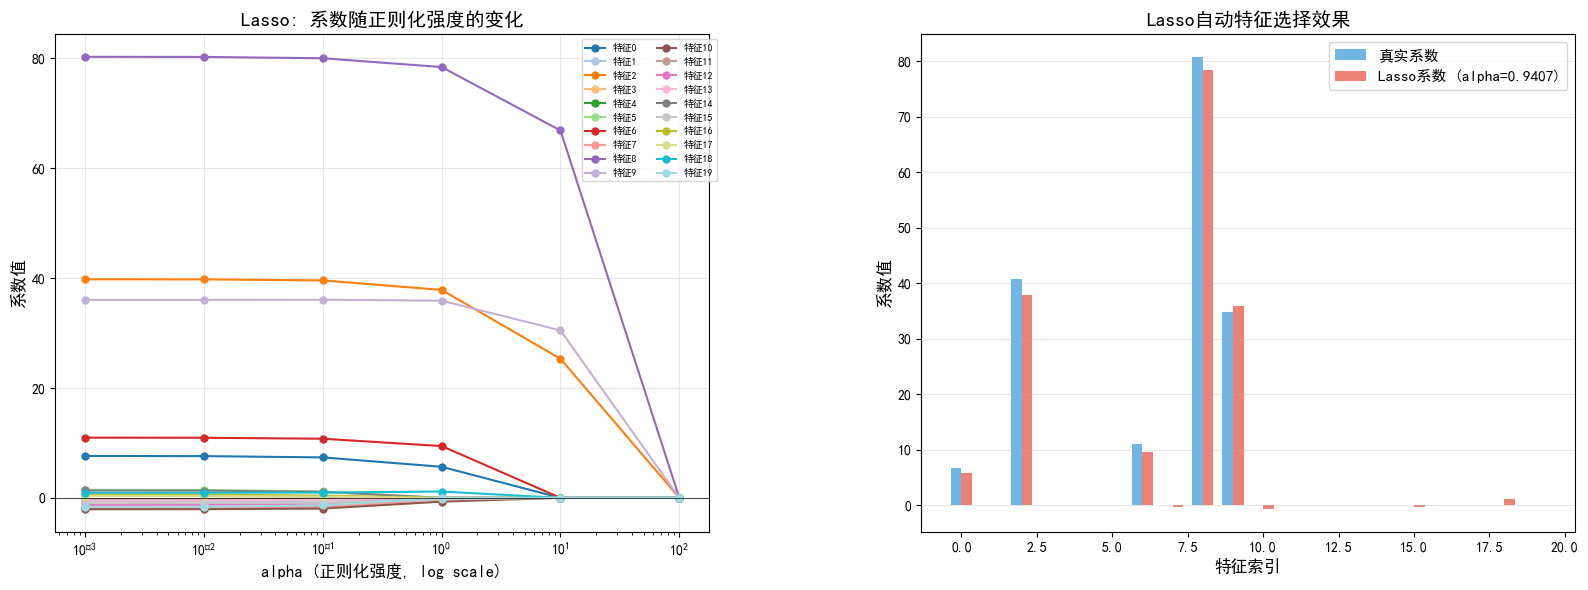

In [18]:
# ====== L1正则化（Lasso）实验 ======
from sklearn.datasets import make_regression
from sklearn.linear_model import Lasso, LassoCV

# 生成回归数据（大部分特征无用）
X_reg, y_reg, true_coef = make_regression(
    n_samples=100, n_features=20, n_informative=5,
    coef=True, noise=10, random_state=42)

print(f"数据维度: {X_reg.shape}")
print(f"真实有用特征数: 5 / 20")
print(f"真实非零系数: {np.where(true_coef != 0)[0].tolist()}")

# 测试不同lambda值
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

print(f"\n{'alpha':>8} | {'非零系数数':>10} | {'MSE':>10} | 非零特征索引")
print("-" * 65)

coef_history = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_reg, y_reg)
    y_pred = lasso.predict(X_reg)
    mse = mean_squared_error(y_reg, y_pred)
    n_nonzero = np.sum(np.abs(lasso.coef_) > 1e-6)
    nonzero_idx = np.where(np.abs(lasso.coef_) > 1e-6)[0].tolist()
    coef_history.append(lasso.coef_.copy())
    print(f"{alpha:>8.3f} | {n_nonzero:>10d} | {mse:>10.2f} | {nonzero_idx}")

# 可视化系数随alpha的变化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：不同alpha下的系数
colors = plt.cm.tab20(np.linspace(0, 1, 20))
for j in range(20):
    coef_vals = [c[j] for c in coef_history]
    axes[0].plot(alphas, coef_vals, 'o-', color=colors[j], linewidth=1.5,
                markersize=5, label=f'特征{j}')

axes[0].set_xscale('log')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_xlabel('alpha (正则化强度, log scale)', fontsize=12)
axes[0].set_ylabel('系数值', fontsize=12)
axes[0].set_title('Lasso: 系数随正则化强度的变化', fontsize=14)
axes[0].legend(bbox_to_anchor=(1.02, 1), fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

# 右图：最优alpha下的系数 vs 真实系数
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_reg, y_reg)

x_pos = np.arange(20)
width = 0.35
axes[1].bar(x_pos - width/2, true_coef, width, color='#3498DB', alpha=0.7,
             label='真实系数')
axes[1].bar(x_pos + width/2, lasso_cv.coef_, width, color='#E74C3C', alpha=0.7,
             label=f'Lasso系数 (alpha={lasso_cv.alpha_:.4f})')

axes[1].set_xlabel('特征索引', fontsize=12)
axes[1].set_ylabel('系数值', fontsize=12)
axes[1].set_title('Lasso自动特征选择效果', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## 4. L2正则化（Ridge）

### 4.1 原理

在损失函数中加入 **L2范数** 惩罚项：

$$J(w) = \frac{1}{N}\sum_{i=1}^{N}L(y_i, \hat{y}_i) + \frac{\lambda}{2}\sum_{j=1}^{d}w_j^2$$

其中 $w_j^2$ 是权重的平方。

### 4.2 L2正则化的核心特性：**参数平滑**

- L2正则化倾向于让所有权重**趋近于0但不等于0**
- 不会产生稀疏解，而是让权重更均匀地分布
- 适合**共线性特征**（高度相关的特征）
- 闭式解：$w^* = (X^TX + \lambda I)^{-1}X^Ty$

### 4.3 L1 vs L2 对比

| 特性 | L1 (Lasso) | L2 (Ridge) |
|------|-----------|------------|
| 惩罚项 | $\sum|w_j|$ | $\sum w_j^2$ |
| 稀疏性 | 产生0系数 | 不产生0系数 |
| 特征选择 | 自动进行 | 不会自动选择 |
| 共线性处理 | 随机选一个 | 均匀分配权重 |
| 解的形式 | 无闭式解 | 有闭式解 |
| 适用场景 | 高维稀疏特征 | 特征共线性强 |

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


     alpha |        非零系数数 |       最大系数 |        MSE
-------------------------------------------------------
     0.001 |           20 |      80.25 |      64.60
     0.010 |           20 |      80.24 |      64.60
     0.100 |           20 |      80.13 |      64.61
     1.000 |           20 |      79.07 |      65.89
    10.000 |           20 |      70.11 |     161.54
   100.000 |           20 |      34.74 |    2299.66
  1000.000 |           20 |       6.05 |    7107.91


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


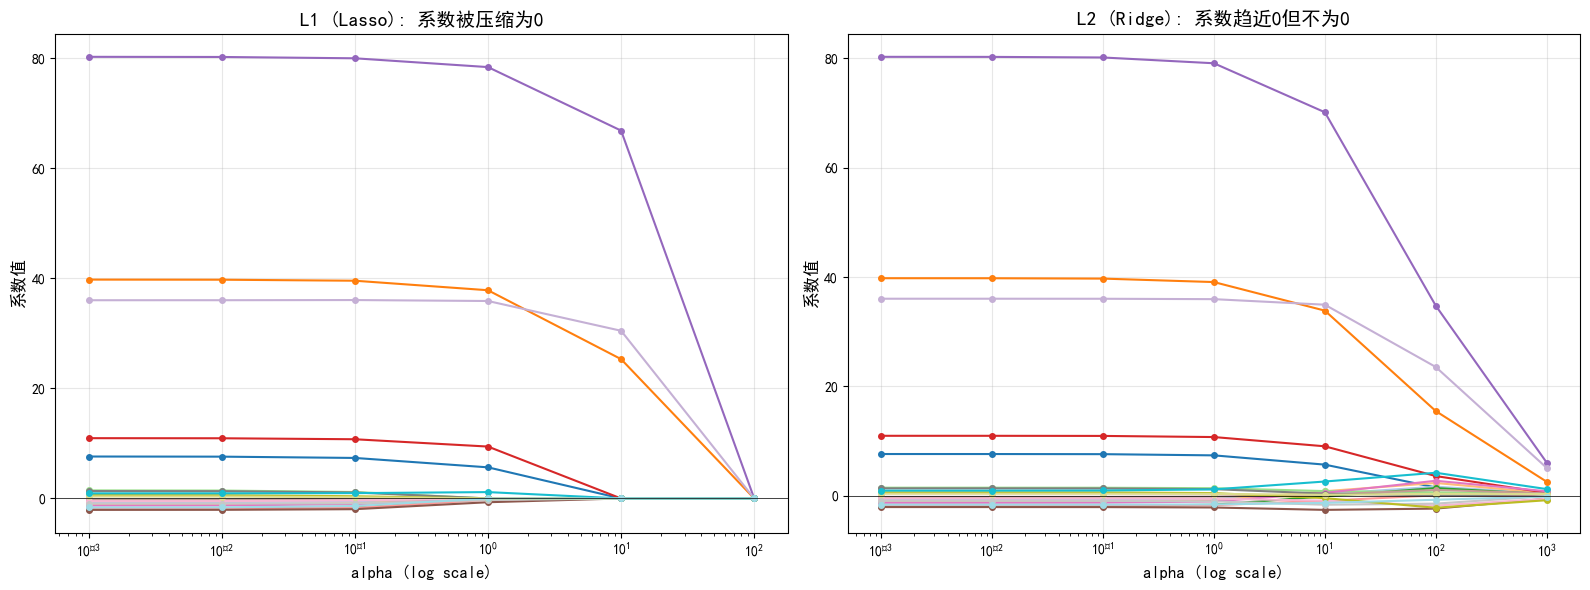


RidgeCV最优alpha: 0.0010


In [19]:
# ====== L2正则化（Ridge）实验 ======
from sklearn.linear_model import Ridge, RidgeCV

alphas_ridge = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

print(f"{'alpha':>10} | {'非零系数数':>12} | {'最大系数':>10} | {'MSE':>10}")
print("-" * 55)

coef_history_ridge = []
for alpha in alphas_ridge:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_reg, y_reg)
    y_pred = ridge.predict(X_reg)
    mse = mean_squared_error(y_reg, y_pred)
    n_nonzero = np.sum(np.abs(ridge.coef_) > 1e-6)
    coef_history_ridge.append(ridge.coef_.copy())
    print(f"{alpha:>10.3f} | {n_nonzero:>12d} | {np.max(np.abs(ridge.coef_)):>10.2f} | {mse:>10.2f}")

# 可视化 L1 vs L2 对比
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# L1 (Lasso)
for j in range(20):
    coef_vals = [c[j] for c in coef_history]
    axes[0].plot(alphas, coef_vals, 'o-', color=colors[j], linewidth=1.5, markersize=4)
axes[0].set_xscale('log')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_xlabel('alpha (log scale)', fontsize=12)
axes[0].set_ylabel('系数值', fontsize=12)
axes[0].set_title('L1 (Lasso): 系数被压缩为0', fontsize=14)
axes[0].grid(True, alpha=0.3)

# L2 (Ridge)
for j in range(20):
    coef_vals = [c[j] for c in coef_history_ridge]
    axes[1].plot(alphas_ridge, coef_vals, 'o-', color=colors[j], linewidth=1.5, markersize=4)
axes[1].set_xscale('log')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_xlabel('alpha (log scale)', fontsize=12)
axes[1].set_ylabel('系数值', fontsize=12)
axes[1].set_title('L2 (Ridge): 系数趋近0但不为0', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 使用RidgeCV自动选择最优alpha
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge_cv.fit(X_reg, y_reg)
print(f"\nRidgeCV最优alpha: {ridge_cv.alpha_:.4f}")

---

## 5. Elastic Net（L1 + L2 结合）

### 5.1 原理

Elastic Net 同时使用 L1 和 L2 正则化：

$$J(w) = \frac{1}{N}\sum_{i=1}^{N}L(y_i, \hat{y}_i) + \lambda_1 \sum_{j=1}^{d}|w_j| + \frac{\lambda_2}{2}\sum_{j=1}^{d}w_j^2$$

通常用两个超参数表示：
- $\alpha = \lambda_1 + \lambda_2$（总正则化强度）
- $\rho = \frac{\lambda_1}{\lambda_1 + \lambda_2}$（L1比例，0~1）

$$J(w) = \frac{1}{2N}\|y - Xw\|^2 + \alpha \cdot \rho \cdot \|w\|_1 + \frac{\alpha(1-\rho)}{2}\|w\|_2^2$$

### 5.2 优势

- 兼具 L1 的**稀疏性**和 L2 的**稳定性**
- 当特征间有强相关性时，Elastic Net 比 Lasso 更稳定
- Lasso 可能只选一个相关特征，Elastic Net 会倾向于一起选或一起不选

> 🎯 **NOAI竞赛建议**：Elastic Net 是一个安全的选择，它结合了两种正则化的优点。

=== 三种正则化方法对比 ===
特征0和1高度相关，特征3和4高度相关
真实模型使用特征0(w=3)和特征3(w=2)

  特征 |       真实 |      Lasso |      Ridge |   ElasticNet |      EN-CV
--------------------------------------------------------------
   0 |      3.0 |      2.791 |      1.931 |        1.510 |      1.906
   1 |      0.0 |      0.000 |      0.988 |        1.251 |      0.880
   2 |      0.0 |      0.000 |     -0.008 |        0.000 |      0.000
   3 |      2.0 |      1.246 |      1.123 |        0.903 |      0.974
   4 |      0.0 |      0.528 |      0.764 |        0.874 |      0.805
   5 |      0.0 |     -0.000 |     -0.064 |       -0.000 |     -0.000
   6 |      0.0 |     -0.000 |     -0.031 |       -0.000 |     -0.000
   7 |      0.0 |      0.000 |      0.040 |        0.000 |      0.000
   8 |      0.0 |     -0.000 |     -0.103 |       -0.002 |     -0.000
   9 |      0.0 |      0.000 |      0.046 |        0.017 |      0.000

ElasticNetCV最优参数: alpha=0.0953, l1_ratio=0.9000


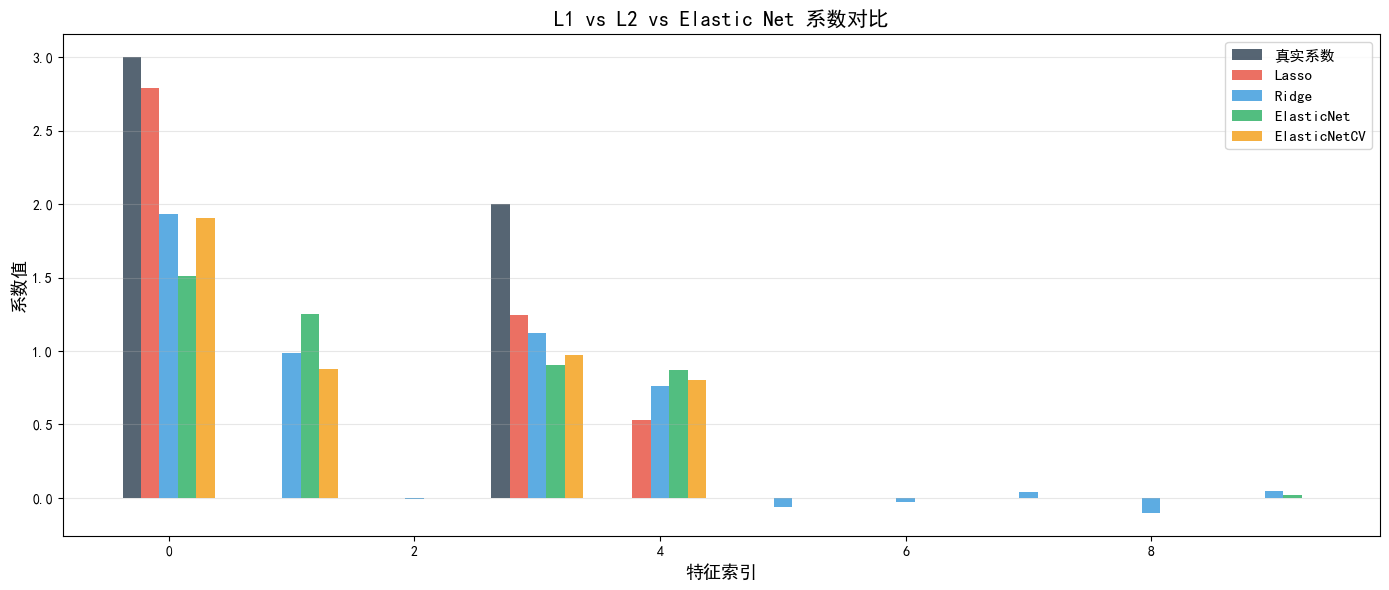

In [20]:
# ====== Elastic Net 实验 ======
from sklearn.linear_model import ElasticNet, ElasticNetCV

# 创建具有相关特征的数据
np.random.seed(42)
n_samples = 100
# 特征1和2高度相关
X_corr = np.random.randn(n_samples, 10)
X_corr[:, 1] = X_corr[:, 0] + 0.1 * np.random.randn(n_samples)  # 特征1约等于特征2
X_corr[:, 4] = X_corr[:, 3] + 0.1 * np.random.randn(n_samples)  # 特征4约等于特征5

# 真实模型：使用特征0和3
true_w = np.array([3, 0, 0, 2, 0, 0, 0, 0, 0, 0], dtype=float)
y_corr = X_corr @ true_w + np.random.randn(n_samples) * 1

print("=== 三种正则化方法对比 ===")
print(f"特征0和1高度相关，特征3和4高度相关")
print(f"真实模型使用特征0(w=3)和特征3(w=2)\n")

# Lasso
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_corr, y_corr)

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_corr, y_corr)

# Elastic Net
enet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
enet.fit(X_corr, y_corr)

# ElasticNetCV
enet_cv = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], cv=5, max_iter=10000)
enet_cv.fit(X_corr, y_corr)

print(f"{'特征':>4} | {'真实':>8} | {'Lasso':>10} | {'Ridge':>10} | {'ElasticNet':>12} | {'EN-CV':>10}")
print("-" * 62)
for j in range(10):
    print(f"  {j:>2d} | {true_w[j]:>8.1f} | {lasso.coef_[j]:>10.3f} | {ridge.coef_[j]:>10.3f} "
          f"| {enet.coef_[j]:>12.3f} | {enet_cv.coef_[j]:>10.3f}")

print(f"\nElasticNetCV最优参数: alpha={enet_cv.alpha_:.4f}, l1_ratio={enet_cv.l1_ratio_:.4f}")

# 可视化
fig, ax = plt.subplots(figsize=(14, 6))

x_pos = np.arange(10)
width = 0.15

ax.bar(x_pos - 2*width, true_w, width, color='#2C3E50', alpha=0.8, label='真实系数')
ax.bar(x_pos - width, lasso.coef_, width, color='#E74C3C', alpha=0.8, label='Lasso')
ax.bar(x_pos, ridge.coef_, width, color='#3498DB', alpha=0.8, label='Ridge')
ax.bar(x_pos + width, enet.coef_, width, color='#27AE60', alpha=0.8, label='ElasticNet')
ax.bar(x_pos + 2*width, enet_cv.coef_, width, color='#F39C12', alpha=0.8, label='ElasticNetCV')

ax.set_xlabel('特征索引', fontsize=13)
ax.set_ylabel('系数值', fontsize=13)
ax.set_title('L1 vs L2 vs Elastic Net 系数对比', fontsize=15)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## 6. Early Stopping（早停法）

### 6.1 原理

Early Stopping是一种在**迭代训练过程**中防止过拟合的方法：

1. 在每个epoch结束后，计算验证集误差
2. 如果验证集误差连续 $p$ 个epoch没有下降（或反而上升），则停止训练
3. 保留验证集误差最小时的模型参数

```
训练轮次 ->
验证误差:  下降...下降...下降 -> 上升...上升
                               ^
                          在这里停止！
```

### 6.2 为什么Early Stopping有效？

- 训练初期：模型学习数据的真实模式，验证误差下降
- 训练后期：模型开始记忆噪声和细节，验证误差上升
- Early Stopping在验证误差开始上升时停止，避免过拟合

### 6.3 与正则化的关系

研究表明，Early Stopping在数学上等价于一种正则化。它隐含地限制了模型的**有效参数空间**。

c:\ProgramData\Anaconda3\envs\py311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\Anaconda3\envs\py311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


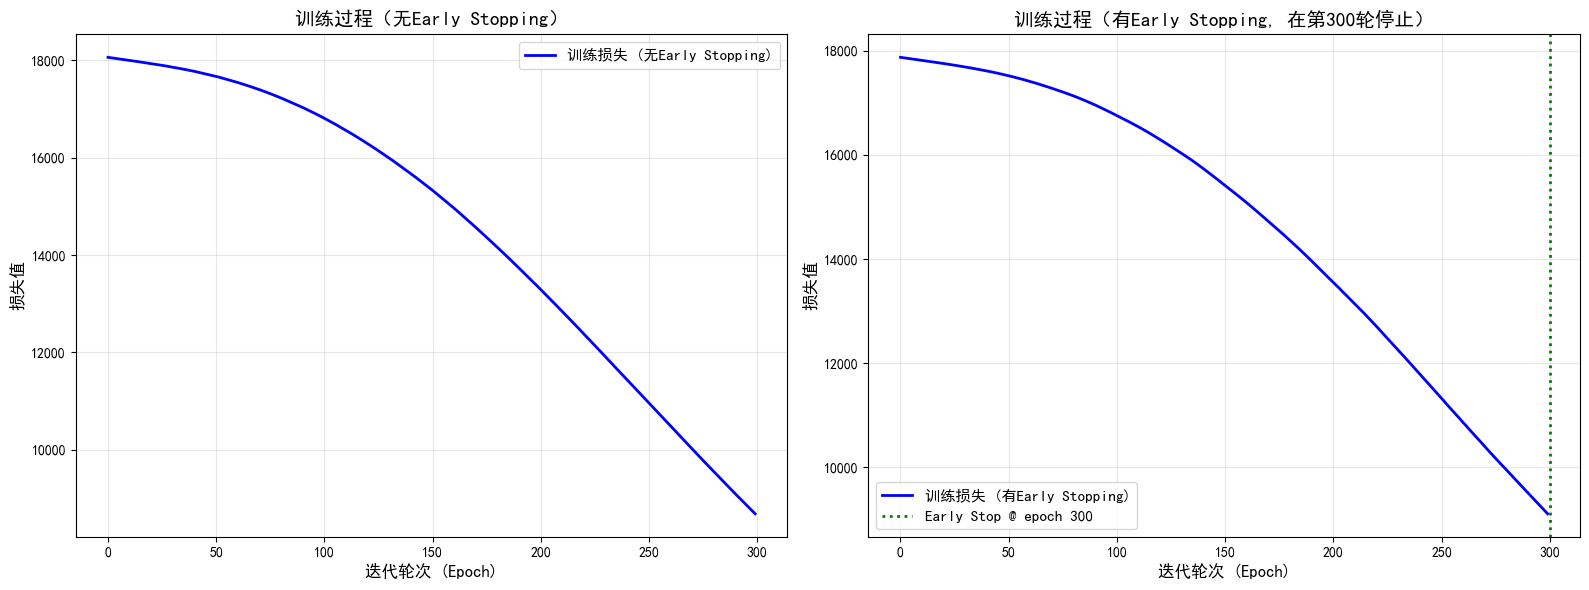

无Early Stopping: 训练了 300 轮
有Early Stopping: 训练了 300 轮 (节省了 0 轮)


c:\ProgramData\Anaconda3\envs\py311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



测试集MSE对比:
  无Early Stopping: 17807.50
  有Early Stopping: 19838.43
  改善: -11.4%


c:\ProgramData\Anaconda3\envs\py311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [21]:
# ====== Early Stopping 实验, 增强稳定性/防溢出修复 ======
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

# 生成回归数据
X_es, y_es = make_regression(n_samples=300, n_features=10, noise=20, random_state=42)

# ====== 数据标准化：防止MLP爆炸 ======
scaler_es = StandardScaler()
X_es_scaled = scaler_es.fit_transform(X_es)

# ValueError&溢出 错误修复建议：
# 1. 降低学习率
# 2. 换用'adam'优化器（通常比'sgd'更稳定，防止权重发散）
# 3. 增加L2正则项（alpha）
# 4. 限制最大迭代轮数&隐藏层神经元数量

# ====== 降低学习率，并用adam优化器，添加L2正则 ======
mlp_no_es = MLPRegressor(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',  # adam更稳定
    alpha=0.01,     # 增加L2正则
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=False,
    random_state=42,
    validation_fraction=0.2,
)

mlp_no_es.fit(X_es_scaled, y_es)

mlp_es = MLPRegressor(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    alpha=0.01,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42,
    validation_fraction=0.2,
)

mlp_es.fit(X_es_scaled, y_es)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：损失曲线
axes[0].plot(mlp_no_es.loss_curve_, 'b-', linewidth=2, label='训练损失 (无Early Stopping)')
axes[0].set_xlabel('迭代轮次 (Epoch)', fontsize=12)
axes[0].set_ylabel('损失值', fontsize=12)
axes[0].set_title('训练过程（无Early Stopping）', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 右图：Early Stopping效果
axes[1].plot(mlp_es.loss_curve_, 'b-', linewidth=2, label='训练损失 (有Early Stopping)')
n_iters_es = len(mlp_es.loss_curve_)
axes[1].axvline(x=n_iters_es, color='green', linestyle=':', linewidth=2,
                label=f'Early Stop @ epoch {n_iters_es}')
axes[1].set_xlabel('迭代轮次 (Epoch)', fontsize=12)
axes[1].set_ylabel('损失值', fontsize=12)
axes[1].set_title(f'训练过程（有Early Stopping, 在第{n_iters_es}轮停止）', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"无Early Stopping: 训练了 {len(mlp_no_es.loss_curve_)} 轮")
print(f"有Early Stopping: 训练了 {len(mlp_es.loss_curve_)} 轮 (节省了 {len(mlp_no_es.loss_curve_)-len(mlp_es.loss_curve_)} 轮)")

# 性能对比（分训练测试集，独立Scaler，防止lookahead）
X_train_es, X_test_es, y_train_es, y_test_es = train_test_split(X_es, y_es, test_size=0.2, random_state=42)
scaler_split = StandardScaler()
X_train_es_scaled = scaler_split.fit_transform(X_train_es)
X_test_es_scaled = scaler_split.transform(X_test_es)

mlp_no_es2 = MLPRegressor(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    alpha=0.01,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=False,
    random_state=42
)
mlp_es2 = MLPRegressor(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    alpha=0.01,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)

mlp_no_es2.fit(X_train_es_scaled, y_train_es)
mlp_es2.fit(X_train_es_scaled, y_train_es)

mse_no = mean_squared_error(y_test_es, mlp_no_es2.predict(X_test_es_scaled))
mse_es = mean_squared_error(y_test_es, mlp_es2.predict(X_test_es_scaled))

print(f"\n测试集MSE对比:")
print(f"  无Early Stopping: {mse_no:.2f}")
print(f"  有Early Stopping: {mse_es:.2f}")
if mse_no > 0:
    print(f"  改善: {(mse_no-mse_es)/mse_no*100:.1f}%")

---

## 7. 综合实战：正则化效果对比

让我们通过一个完整的多项式回归实验，对比不同正则化方法在防止过拟合方面的效果。

=== 高次多项式 (degree=15) + 不同正则化 ===
模型                                  训练MSE     CV-MSE       非零系数
-----------------------------------------------------------------
无正则化 (Linear)                      0.3821 746640043211.2582         15
L1 (Lasso, alpha=0.01)             0.6057    16.5323          4
L2 (Ridge, alpha=1.0)              0.7871    27.2371         15
ElasticNet (alpha=0.01, rho=0.5)     0.6844    18.8796          9


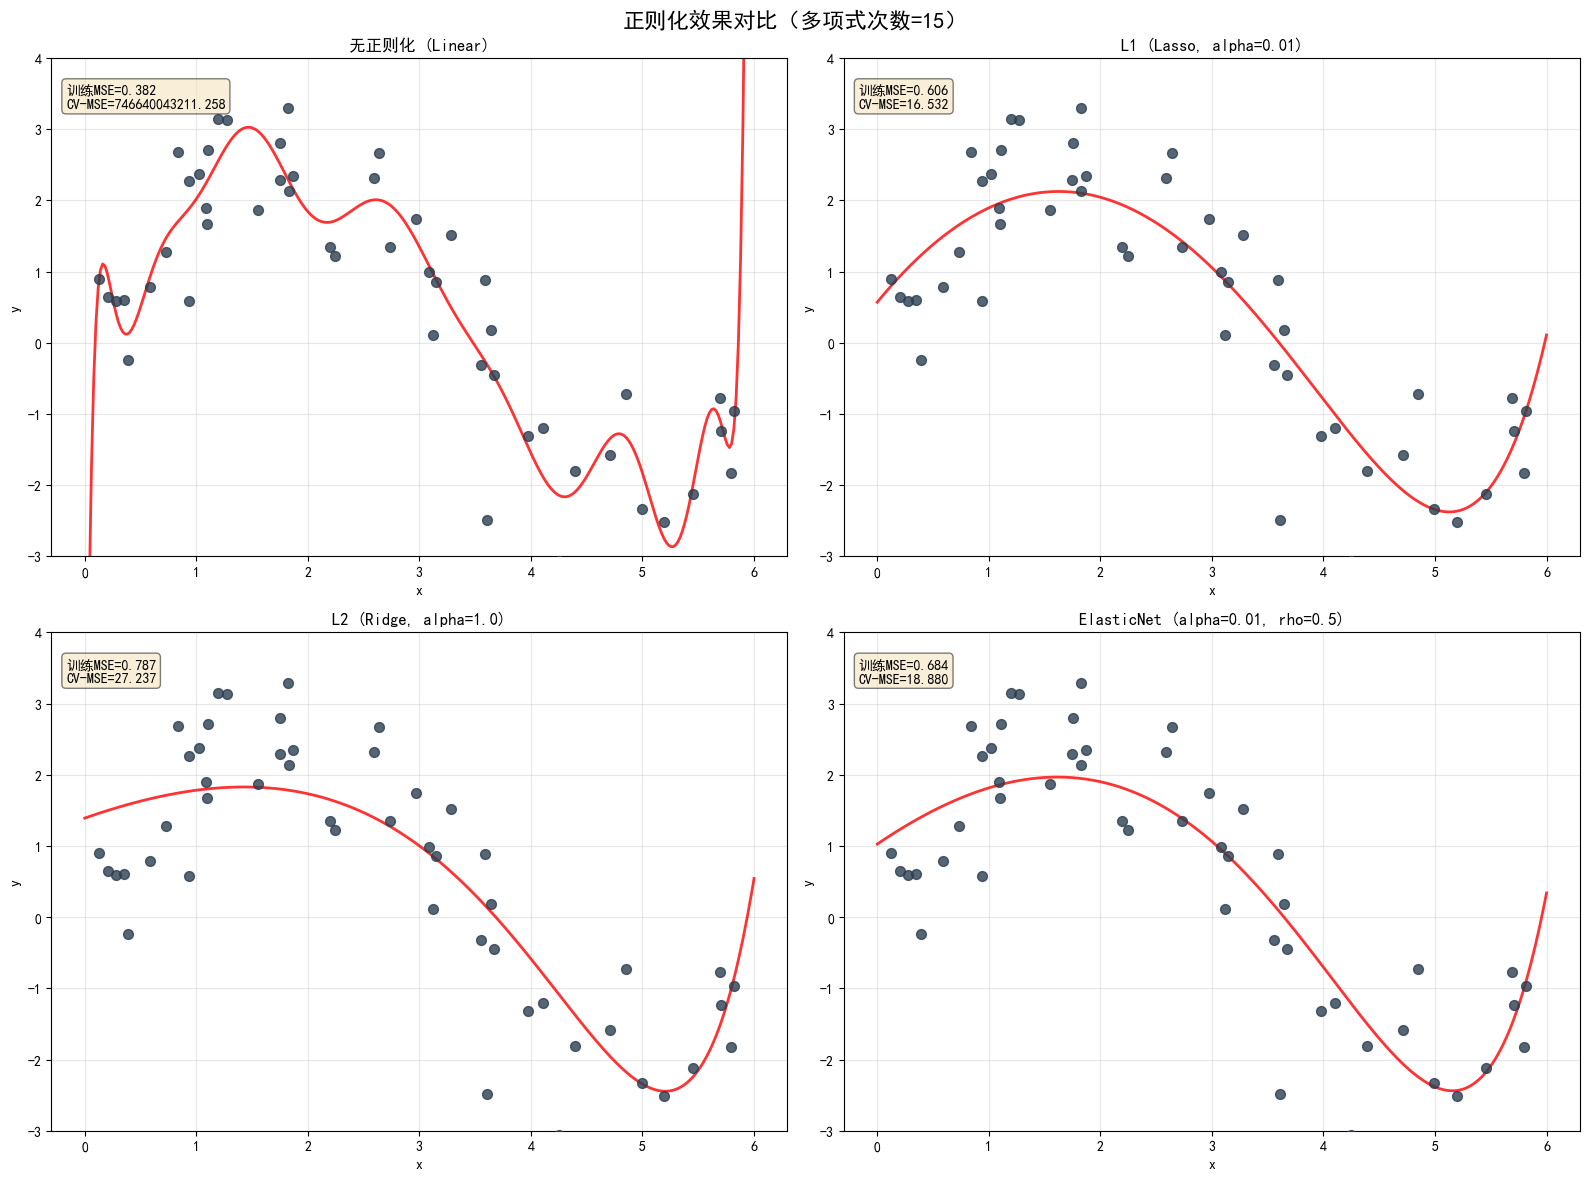

In [22]:
# ====== 综合对比实验 ======
from sklearn.preprocessing import StandardScaler

# 生成更复杂的非线性数据
np.random.seed(42)
n = 50
X_complex = np.sort(6 * np.random.rand(n))
y_complex = 2 * np.sin(X_complex) + 0.5 * X_complex - 0.1 * X_complex**2 + np.random.randn(n) * 0.8

X_c2d = X_complex.reshape(-1, 1)
X_test_c = np.linspace(0, 6, 300).reshape(-1, 1)

# 高次多项式（容易过拟合）
degree = 15
poly = PolynomialFeatures(degree=degree, include_bias=False)

X_poly_train = poly.fit_transform(X_c2d)
X_poly_test = poly.transform(X_test_c)

# 标准化（正则化需要标准化！）
scaler = StandardScaler()
X_poly_train_s = scaler.fit_transform(X_poly_train)
X_poly_test_s = scaler.transform(X_poly_test)

# 四种模型
models_comp = {
    '无正则化 (Linear)': LinearRegression(),
    'L1 (Lasso, alpha=0.01)': Lasso(alpha=0.01, max_iter=10000),
    'L2 (Ridge, alpha=1.0)': Ridge(alpha=1.0),
    'ElasticNet (alpha=0.01, rho=0.5)': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
}

# 使用交叉验证评估
print("=== 高次多项式 (degree=15) + 不同正则化 ===")
print(f"{'模型':<30} {'训练MSE':>10} {'CV-MSE':>10} {'非零系数':>10}")
print("-" * 65)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (name, mdl) in enumerate(models_comp.items()):
    mdl.fit(X_poly_train_s, y_complex)
    y_train_pred = mdl.predict(X_poly_train_s)
    y_test_pred = mdl.predict(X_poly_test_s)

    train_mse = mean_squared_error(y_complex, y_train_pred)
    cv_scores = cross_val_score(mdl, X_poly_train_s, y_complex, cv=5, scoring='neg_mean_squared_error')
    cv_mse = -cv_scores.mean()
    n_nonzero = np.sum(np.abs(mdl.coef_) > 1e-6)

    print(f"{name:<30} {train_mse:>10.4f} {cv_mse:>10.4f} {n_nonzero:>10d}")

    # 绘制
    ax = axes[i]
    ax.scatter(X_complex, y_complex, color='#2C3E50', s=50, zorder=5, alpha=0.8)
    ax.plot(X_test_c.ravel(), y_test_pred, 'r-', linewidth=2, alpha=0.8)
    ax.set_ylim(-3, 4)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)

    # 添加性能文字
    ax.text(0.02, 0.95, f'训练MSE={train_mse:.3f}\nCV-MSE={cv_mse:.3f}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'正则化效果对比（多项式次数={degree}）', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 8. 练习题

### 📝 练习1：诊断过拟合/欠拟合

给定以下训练结果，判断模型状态并给出改进建议：

| 模型 | 训练准确率 | 验证准确率 |
|------|-----------|-----------|
| A | 99.9% | 65.0% |
| B | 55.0% | 54.0% |
| C | 85.0% | 82.0% |

In [23]:
# 练习1：诊断与分析
print("=== 模型诊断 ===")
print()

cases = {
    'A': {'train': 0.999, 'val': 0.650, 'gap': 0.999-0.650},
    'B': {'train': 0.550, 'val': 0.540, 'gap': 0.550-0.540},
    'C': {'train': 0.850, 'val': 0.820, 'gap': 0.850-0.820}
}

for name, info in cases.items():
    gap = info['gap']
    if info['train'] > 0.9 and gap > 0.15:
        status = '过拟合 (Overfitting)'
        suggestion = '-> 增加正则化、减少模型复杂度、增加数据、使用Dropout'
    elif info['train'] < 0.7 and info['val'] < 0.7:
        status = '欠拟合 (Underfitting)'
        suggestion = '-> 增加模型复杂度、增加特征、减少正则化、训练更久'
    elif gap < 0.05:
        status = '良好 (Good Fit)'
        suggestion = '-> 模型状态良好，可尝试微调进一步提升'
    else:
        status = '轻微过拟合'
        suggestion = '-> 可适当增加正则化'

    print(f"模型{name}: 训练={info['train']*100:.1f}%, 验证={info['val']*100:.1f}%, 差距={gap*100:.1f}%")
    print(f"  诊断: {status}")
    print(f"  建议: {suggestion}")
    print()

=== 模型诊断 ===

模型A: 训练=99.9%, 验证=65.0%, 差距=34.9%
  诊断: 过拟合 (Overfitting)
  建议: -> 增加正则化、减少模型复杂度、增加数据、使用Dropout

模型B: 训练=55.0%, 验证=54.0%, 差距=1.0%
  诊断: 欠拟合 (Underfitting)
  建议: -> 增加模型复杂度、增加特征、减少正则化、训练更久

模型C: 训练=85.0%, 验证=82.0%, 差距=3.0%
  诊断: 良好 (Good Fit)
  建议: -> 模型状态良好，可尝试微调进一步提升



### 📝 练习2：正则化强度寻优

对Ridge回归，绘制不同alpha值下的训练MSE和验证MSE曲线，找到最优alpha。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


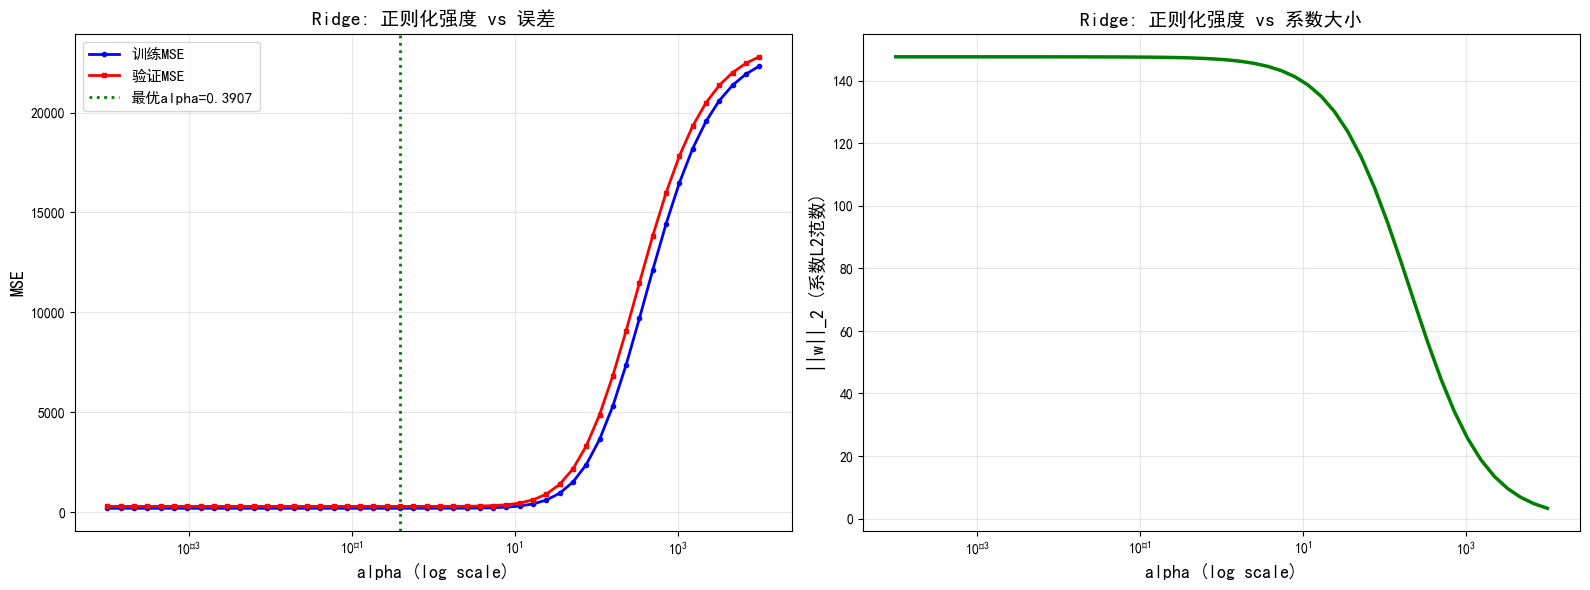


最优alpha: 0.3907
对应验证MSE: 277.11


In [24]:
# 练习2：正则化强度寻优
from sklearn.model_selection import validation_curve

# 使用回归数据
X_r, y_r = make_regression(n_samples=200, n_features=30, n_informative=10,
                           noise=15, random_state=42)

scaler_r = StandardScaler()
X_r_s = scaler_r.fit_transform(X_r)

# Ridge正则化强度范围
param_range = np.logspace(-4, 4, 50)

train_scores, val_scores = validation_curve(
    Ridge(), X_r_s, y_r,
    param_name='alpha',
    param_range=param_range,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

train_mse_mean = -train_scores.mean(axis=1)
val_mse_mean = -val_scores.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：训练/验证MSE
axes[0].semilogx(param_range, train_mse_mean, 'b-o', markersize=3,
                 linewidth=2, label='训练MSE')
axes[0].semilogx(param_range, val_mse_mean, 'r-s', markersize=3,
                 linewidth=2, label='验证MSE')

optimal_idx = np.argmin(val_mse_mean)
axes[0].axvline(x=param_range[optimal_idx], color='green', linestyle=':',
                 linewidth=2, label=f'最优alpha={param_range[optimal_idx]:.4f}')

axes[0].set_xlabel('alpha (log scale)', fontsize=13)
axes[0].set_ylabel('MSE', fontsize=13)
axes[0].set_title('Ridge: 正则化强度 vs 误差', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 右图：系数范数
coef_norms = []
for alpha in param_range:
    r = Ridge(alpha=alpha).fit(X_r_s, y_r)
    coef_norms.append(np.linalg.norm(r.coef_))

axes[1].semilogx(param_range, coef_norms, 'g-', linewidth=2.5)
axes[1].set_xlabel('alpha (log scale)', fontsize=13)
axes[1].set_ylabel('||w||_2 (系数L2范数)', fontsize=13)
axes[1].set_title('Ridge: 正则化强度 vs 系数大小', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n最优alpha: {param_range[optimal_idx]:.4f}")
print(f"对应验证MSE: {val_mse_mean[optimal_idx]:.2f}")

### 📝 练习3（挑战）：实战竞赛数据

使用sklearn的 `fetch_california_housing` 数据集：
1. 比较Linear Regression、Ridge、Lasso、Elastic Net
2. 使用交叉验证评估每种方法
3. 使用网格搜索找到最优超参数
4. 分析特征重要性

加州房价数据集: 20640个样本, 8个特征
特征: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

模型                            CV-MSE均值    CV-MSE标准差
-------------------------------------------------------
Linear Regression               0.5510       0.1929
Ridge (alpha=1)                 0.5509       0.1929
Lasso (alpha=0.01)              0.5575       0.2135
ElasticNet (alpha=0.01)         0.5542       0.2064

⏳ ElasticNet网格搜索...
最优参数: {'alpha': 0.001, 'l1_ratio': 0.9}
最优CV-MSE: 0.5580

=== 特征重要性（按|系数|排序）===
   1. Latitude     系数= -0.8889
   2. Longitude    系数= -0.8589
   3. MedInc       系数=  0.8249
   4. AveBedrms    系数=  0.2931
   5. AveRooms     系数= -0.2530
   6. HouseAge     系数=  0.1197
   7. AveOccup     系数= -0.0385
   8. Population   系数= -0.0032


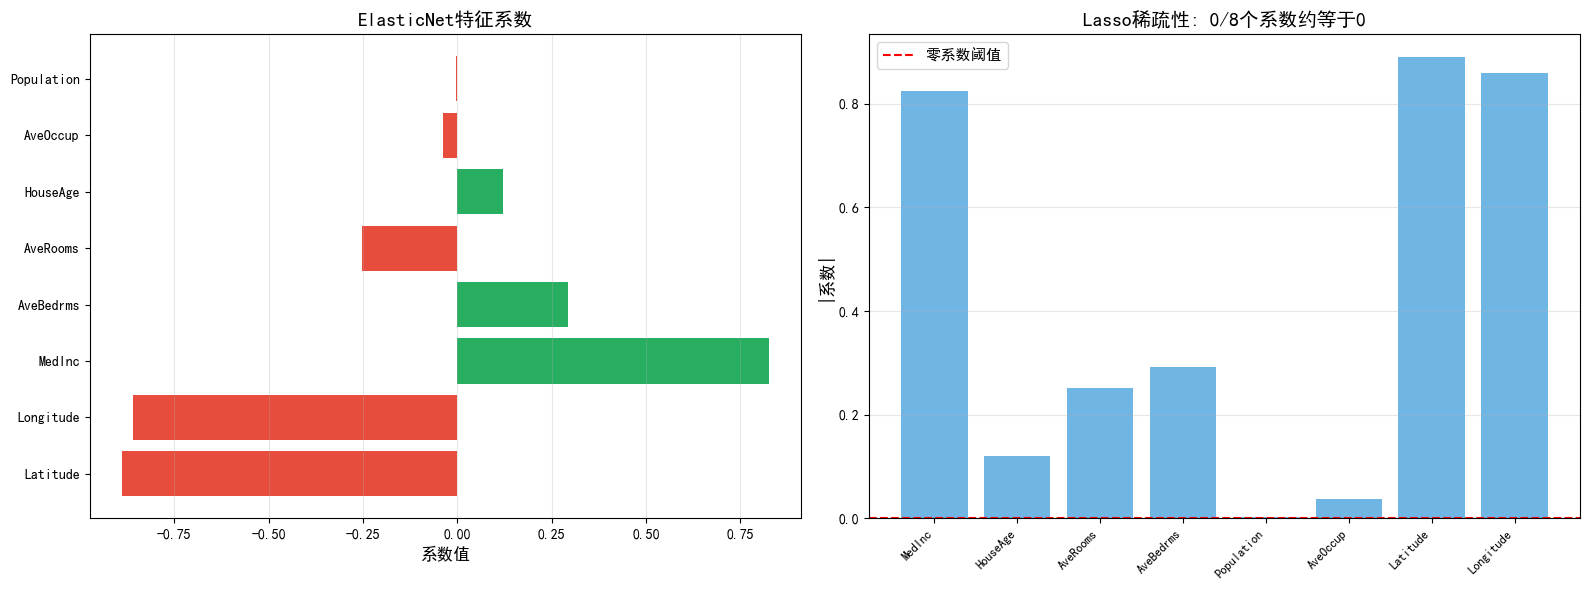

In [25]:
# 练习3：加州房价数据集实战
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import GridSearchCV

housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target
feature_names = housing.feature_names

print(f"加州房价数据集: {X_h.shape[0]}个样本, {X_h.shape[1]}个特征")
print(f"特征: {feature_names}")

scaler_h = StandardScaler()
X_h_s = scaler_h.fit_transform(X_h)

# 四种模型对比
models_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1)': Ridge(alpha=1.0),
    'Lasso (alpha=0.01)': Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet (alpha=0.01)': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
}

print(f"\n{'模型':<25} {'CV-MSE均值':>12} {'CV-MSE标准差':>12}")
print("-" * 55)

for name, mdl in models_reg.items():
    scores = cross_val_score(mdl, X_h_s, y_h, cv=10, scoring='neg_mean_squared_error')
    mse_mean = -scores.mean()
    mse_std = scores.std()
    print(f"{name:<25} {mse_mean:>12.4f} {mse_std:>12.4f}")

# 网格搜索ElasticNet
print("\n⏳ ElasticNet网格搜索...")
en_grid = GridSearchCV(
    ElasticNet(max_iter=10000),
    {'alpha': [0.001, 0.01, 0.1, 1],
     'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
en_grid.fit(X_h_s, y_h)

print(f"最优参数: {en_grid.best_params_}")
print(f"最优CV-MSE: {-en_grid.best_score_:.4f}")

# 分析特征重要性（用最优ElasticNet的系数）
best_en = en_grid.best_estimator_
coefs = best_en.coef_

# 排序
sorted_idx = np.argsort(np.abs(coefs))[::-1]

print(f"\n=== 特征重要性（按|系数|排序）===")
for rank, idx in enumerate(sorted_idx, 1):
    print(f"  {rank:>2d}. {feature_names[idx]:<12} 系数={coefs[idx]:>8.4f}")

# 可视化特征重要性
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sorted_features = [feature_names[i] for i in sorted_idx]
sorted_coefs = coefs[sorted_idx]

colors_bar = ['#E74C3C' if c < 0 else '#27AE60' for c in sorted_coefs]
axes[0].barh(range(len(sorted_features)), sorted_coefs, color=colors_bar)
axes[0].set_yticks(range(len(sorted_features)))
axes[0].set_yticklabels(sorted_features)
axes[0].set_xlabel('系数值', fontsize=12)
axes[0].set_title('ElasticNet特征系数', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='x')

# L1稀疏性展示
lasso_final = Lasso(alpha=en_grid.best_params_['alpha'], max_iter=10000).fit(X_h_s, y_h)
axes[1].bar(range(len(feature_names)), np.abs(lasso_final.coef_), color='#3498DB', alpha=0.7)
axes[1].axhline(y=1e-6, color='red', linestyle='--', linewidth=1.5, label='零系数阈值')
axes[1].set_xticks(range(len(feature_names)))
axes[1].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('|系数|', fontsize=12)
n_zero = np.sum(np.abs(lasso_final.coef_) < 1e-6)
axes[1].set_title(f'Lasso稀疏性: {n_zero}/{len(feature_names)}个系数约等于0', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## 📌 本节总结

| 概念 | 核心内容 | 解决方案 |
|------|---------|---------|
| **偏差-方差权衡** | 偏差下降方差上升的平衡 | 选择合适复杂度的模型 |
| **过拟合** | 训练好、测试差 | 正则化、增加数据、Early Stopping、Dropout |
| **欠拟合** | 训练差、测试差 | 增加复杂度、增加特征、训练更久 |
| **L1 (Lasso)** | 稀疏解，自动特征选择 | 适合高维稀疏特征 |
| **L2 (Ridge)** | 参数平滑，不产生0 | 适合共线性特征 |
| **Elastic Net** | L1+L2，兼具两者优点 | 通用性好 |
| **Early Stopping** | 监控验证误差，适时停止 | 迭代模型（NN, GBDT等） |

**关键要点：**
1. 总误差 = 偏差平方 + 方差 + 不可约误差
2. 过拟合和欠拟合可通过训练/验证误差差距来诊断
3. L1产生稀疏解（特征选择），L2产生平滑解（防共线性）
4. Elastic Net是竞赛中的安全选择
5. 正则化前务必标准化特征！
6. Early Stopping是训练大模型时防止过拟合的实用技巧

### 🔗 延伸阅读

- sklearn文档：[Regularization](https://scikit-learn.org/stable/modules/linear_model.html#regularization)
- 论文：*Regularization and Variable Selection via the Elastic Net* (Zou & Hastie, 2005)
- 论文：*A Simple Early Stopping Criterion* (Prechelt, 1998)